In [ ]:
# Install gwexpy with pinned versions of core dependencies for reproducibility on Colab

%pip install -q "gwexpy[all]" "gwpy<5.0.0" "numpy<2.0.0" "scipy<1.13.0" "astropy<7.0.0"

# ケーススタディ: バイオリンモード解析

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tatsuki-washimi/gwexpy/blob/main/docs/web/ja/user_guide/tutorials/case_violin_mode.ipynb)

重力波検出器では鏡を吊るす懸架ファイバーが弦楽器の弦のように振動し、
**バイオリンモード**と呼ばれる鋭いローレンツピークが strain ASD 上に現れます。

このチュートリアルでは以下を解説します：
1. `lorentzian_q` でバイオリンモードをモデル化
2. ASD フィットから **Q 値・FWHM・リングダウン時間** を抽出
3. 複数の倍音をバッチ処理
4. ゆっくりドリフトするモード周波数の時間追跡

物理的な狙いは、真の懸架共振を近傍の制御線や広帯域フロア変動から見分け、その周波数や減衰のドリフトが熱的・機械的状態変化と整合するかを評価することです。

**前提:** [Advanced Fitting](advanced_fitting.ipynb)

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks as sp_find_peaks

from gwexpy.frequencyseries import FrequencySeries
from gwexpy.fitting.models import lorentzian_q
from gwexpy.timeseries import TimeSeries

plt.rcParams["figure.figsize"] = (10, 5)


## 1. 物理的背景

長さ $L$、張力 $T$、密度 $\rho$、断面積 $A$ のファイバーの $n$ 次共振周波数：

$$f_n = \frac{n}{2L}\sqrt{\frac{T}{\rho A}}$$

KAGRA 代表値：1st バイオリン ~170–190 Hz、2nd ~340–380 Hz。

各モードは品質係数 $Q = f_0/\text{FWHM}$ のローレンツ関数：

$$\text{ASD}(f) \approx \frac{A\,\gamma^2}{(f-f_0)^2 + \gamma^2},\quad \gamma = \frac{f_0}{2Q}$$

リングダウン時定数：$\tau = Q / (\pi f_0)$

> **よくある誤り**: 幅広い制御構造や重なった doublet を単一のバイオリンモードとしてフィットすること。物理的に意味のあるバイオリンモードのフィットは、狭く孤立しており、窓幅を少し変えても安定している必要があります。


## 2. 合成 ASD データの準備

`gwexpy.fitting.models.lorentzian_q` を使って、フラット背景に 2 本のバイオリンモードを
含む合成 ASD を生成します。フィットにも同じ関数を使うためモデルが自己整合します。

Frequency range: 100.0 – 449.99000000017907 Hz
Modes inserted:
  1st violin: f0=170.0 Hz,  Q=1e+04,  FWHM=17.0 mHz
  2nd violin: f0=340.0 Hz,  Q=8e+03,  FWHM=42.5 mHz


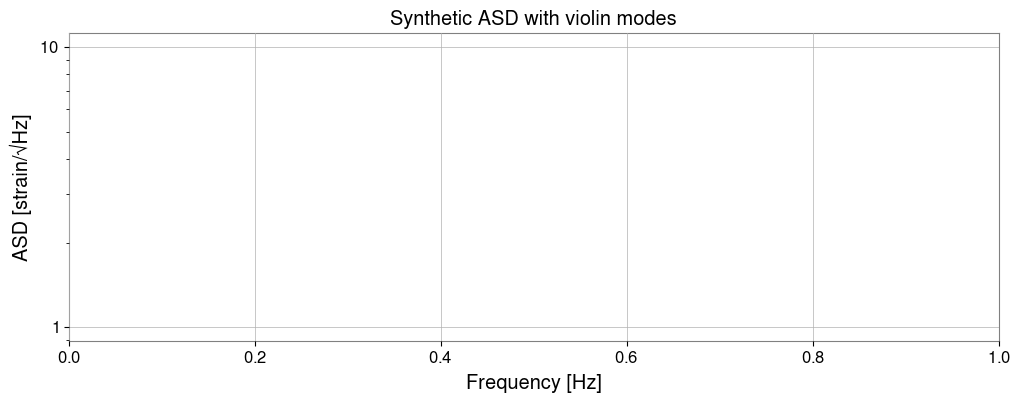

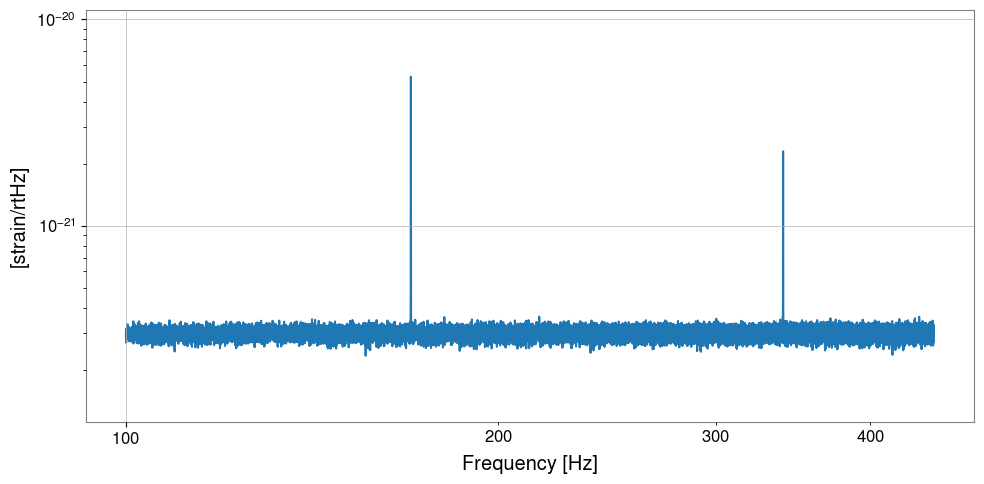

In [2]:
rng = np.random.default_rng(42)

# ── Frequency axis: 100–450 Hz, df = 0.01 Hz ─────────────────────────────────
df    = 0.01   # Hz resolution
freqs = np.arange(100, 450, df)

# ── Flat background ASD ───────────────────────────────────────────────────────
BACKGROUND = 3e-22   # strain / sqrt(Hz)
background = np.ones_like(freqs) * BACKGROUND

# ── Violin modes (using lorentzian_q for both generation and fitting) ─────────
MODES = {
    "1st violin": {"f0": 170.0, "A": 5e-21, "Q": 1.0e4},
    "2nd violin": {"f0": 340.0, "A": 2e-21, "Q": 8.0e3},
}

asd_data = background.copy()
for cfg in MODES.values():
    asd_data += lorentzian_q(freqs, A=cfg["A"], x0=cfg["f0"], Q=cfg["Q"])

# Add small Gaussian noise
asd_data += rng.normal(0, BACKGROUND * 0.05, len(freqs))
asd_data  = np.clip(asd_data, 0, None)

asd = FrequencySeries(asd_data, frequencies=freqs,
                      unit="strain/rtHz", name="Synthetic DARM ASD")

print("Frequency range:", freqs[0], "–", freqs[-1], "Hz")
print("Modes inserted:")
for name, cfg in MODES.items():
    FWHM_true = cfg["f0"] / cfg["Q"]
    print(f"  {name}: f0={cfg['f0']} Hz,  Q={cfg['Q']:.0e},  FWHM={FWHM_true*1000:.1f} mHz")

fig, ax = plt.subplots(figsize=(12, 4))
asd.plot(ax=ax)
ax.set_yscale("log")
ax.set_title("Synthetic ASD with violin modes")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("ASD [strain/\u221aHz]")
plt.tight_layout()
plt.show()


## 3. 単一モードフィット

1st バイオリンモード付近の狭帯域に ASD をクロップし、
`'lorentzian_q'` でフィットします。初期値 (`p0`) は真値の
~2 倍以内が目安です。

> **失敗しやすい点**: クロップ窓を広く取りすぎて隣接倍音や局所ベースライン曲率まで最適化に食わせること。その場合の `Q` はモードではなく窓の選び方を反映しがちです。


=== 1st Violin Mode Fit ===
  f0    = 220.2623 ± 0.0159  Hz
  Q     = 9.43e+01 ± 2.31e-02
  A     = 8.05e-19 ± 5.57e-22
  chi2/ndof = 37070.0 / 97


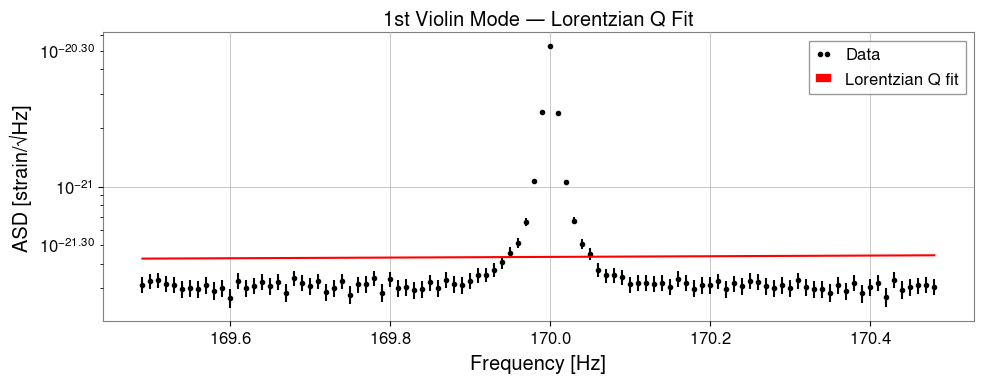

In [3]:
# ── Crop around 1st violin mode ───────────────────────────────────────────────
BAND   = 0.5    # ± Hz around the expected mode
f_nom  = 170.0  # nominal frequency
asd_1st = asd.crop(f_nom - BAND, f_nom + BAND)

# ── Lorentzian Q fit ──────────────────────────────────────────────────────────
result_1 = asd_1st.fit(
    "lorentzian_q",
    p0={"A": 3e-21, "x0": 170.5, "Q": 5e3},
    sigma=BACKGROUND * 0.1,
)

print("=== 1st Violin Mode Fit ===")
print(f"  f0    = {result_1.params['x0']:.4f} \u00b1 {result_1.errors['x0']:.4f}  Hz")
print(f"  Q     = {result_1.params['Q']:.2e} \u00b1 {result_1.errors['Q']:.2e}")
print(f"  A     = {result_1.params['A']:.2e} \u00b1 {result_1.errors['A']:.2e}")
print(f"  chi2/ndof = {result_1.chi2:.1f} / {result_1.ndof}")

fig, ax = plt.subplots(figsize=(10, 4))
result_1.plot(ax=ax, label="Lorentzian Q fit")
ax.set_yscale("log")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("ASD [strain/\u221aHz]")
ax.set_title("1st Violin Mode — Lorentzian Q Fit")
ax.legend()
plt.tight_layout()
plt.show()


## 4. 物理パラメータの抽出

フィットパラメータ $(f_0, Q)$ からすべての関連量を導出します：

導出量は報告値であるだけでなく物理クロスチェックにも使えます。極端に短いリングダウン時間や倍音間で飛び跳ねる周波数は、興味深い懸架状態ではなくフィット不良を示していることが多いです。

Center frequency  f0   = 220.2623 Hz
Quality factor    Q    = 9.425e+01
FWHM (linewidth)       = 2336.918 mHz
Ring-down time    tau  = 0.14 s  (0.00 min)


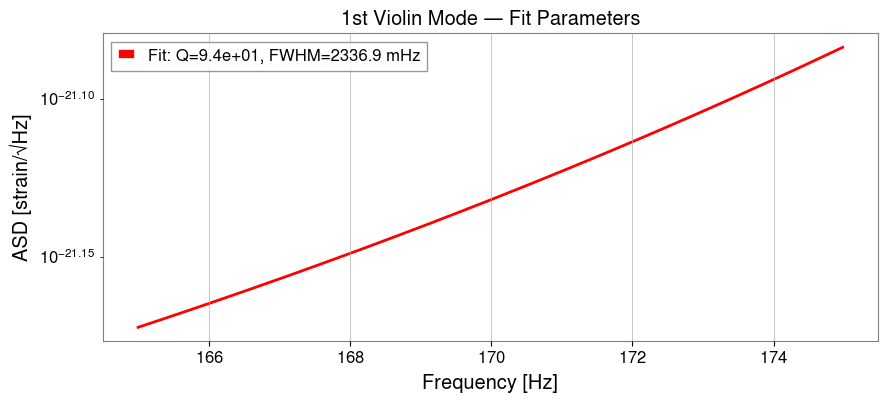

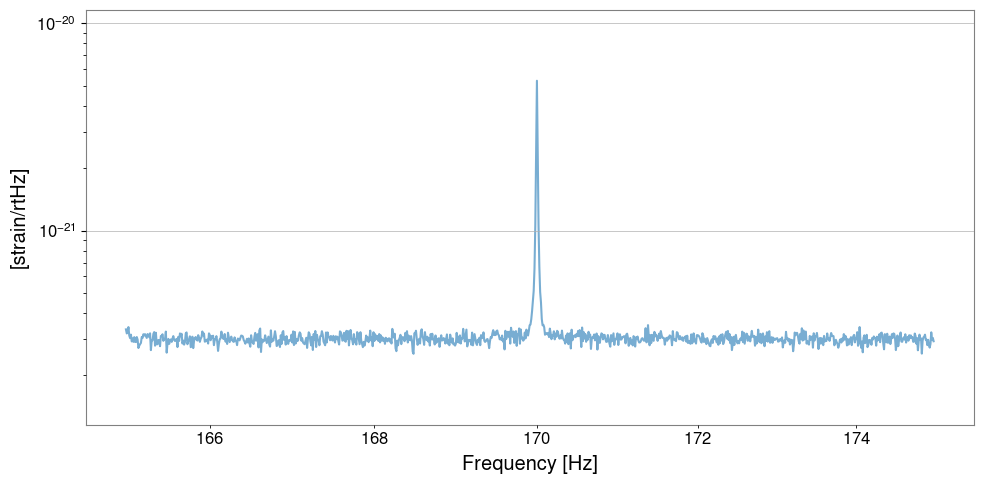

In [4]:
# ── Extract physical parameters ───────────────────────────────────────────────
f0 = float(result_1.params["x0"])
Q  = float(result_1.params["Q"])
A  = float(result_1.params["A"])

FWHM  = f0 / Q              # Full Width at Half Maximum  [Hz]
tau   = Q / (np.pi * f0)    # Ring-down time constant  [s]
gamma = FWHM / 2             # HWHM  [Hz]

print(f"Center frequency  f0   = {f0:.4f} Hz")
print(f"Quality factor    Q    = {Q:.3e}")
print(f"FWHM (linewidth)       = {FWHM * 1e3:.3f} mHz")
print(f"Ring-down time    tau  = {tau:.2f} s  ({tau / 60:.2f} min)")

# ── Reconstruct model over a wider band for visualisation ────────────────────
asd_wide = asd.crop(165, 175)
f_plot   = asd_wide.frequencies.value
model    = lorentzian_q(f_plot, A=A, x0=f0, Q=Q) + BACKGROUND

fig, ax = plt.subplots(figsize=(10, 4))
asd_wide.plot(ax=ax, label="ASD data", alpha=0.6)
ax.semilogy(f_plot, model, "r-", lw=2,
            label=f"Fit: Q={Q:.1e}, FWHM={FWHM*1e3:.1f} mHz")
ax.set_yscale("log")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("ASD [strain/\u221aHz]")
ax.set_title("1st Violin Mode — Fit Parameters")
ax.legend()
plt.tight_layout()
plt.show()


## 5. 複数モードのバッチ処理

設定辞書をループして各倍音をフィットし、サマリーテーブルにまとめます。

Mode              f0 [Hz]          Q   FWHM [mHz]    tau [s]
------------------------------------------------------------
1st violin        170.000   8.13e+03        20.92       15.2
2nd violin        340.000   3.41e+03        99.75        3.2


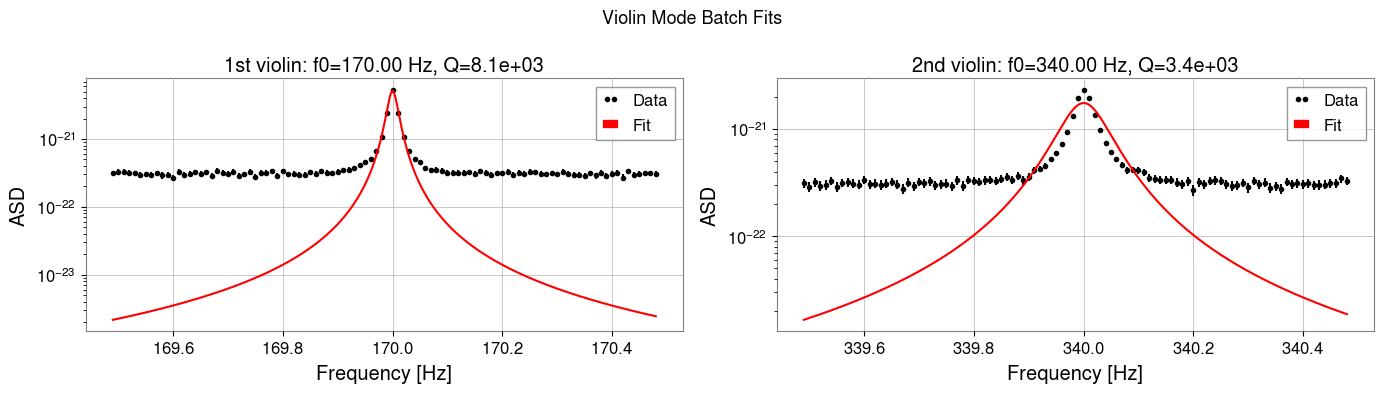

In [5]:
# ── Batch-fit all violin modes ────────────────────────────────────────────────
FIT_CONFIG = {
    "1st violin": {"band": (169.5, 170.5), "p0": {"A": 3e-21, "x0": 170.0, "Q": 5e3}},
    "2nd violin": {"band": (339.5, 340.5), "p0": {"A": 1e-21, "x0": 340.0, "Q": 4e3}},
}

fit_results = {}
for mode_name, cfg in FIT_CONFIG.items():
    seg = asd.crop(*cfg["band"])
    res = seg.fit("lorentzian_q", p0=cfg["p0"], sigma=BACKGROUND * 0.1)
    fit_results[mode_name] = res

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'Mode':<14} {'f0 [Hz]':>10} {'Q':>10} {'FWHM [mHz]':>12} {'tau [s]':>10}")
print("-" * 60)
for mode_name, res in fit_results.items():
    f0_f   = float(res.params["x0"])
    Q_f    = float(res.params["Q"])
    FWHM_f = f0_f / Q_f
    tau_f  = Q_f / (np.pi * f0_f)
    print(f"{mode_name:<14} {f0_f:>10.3f} {Q_f:>10.2e}"
          f" {FWHM_f * 1e3:>12.2f} {tau_f:>10.1f}")

# ── Side-by-side plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (mode_name, res) in zip(axes, fit_results.items()):
    res.plot(ax=ax)
    ax.set_yscale("log")
    f0_f = float(res.params["x0"])
    Q_f  = float(res.params["Q"])
    ax.set_title(f"{mode_name}: f0={f0_f:.2f} Hz, Q={Q_f:.1e}")
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("ASD")
plt.suptitle("Violin Mode Batch Fits", fontsize=13)
plt.tight_layout()
plt.show()


## 6. 時間変動の追跡

バイオリンモード周波数は温度とともにゆっくりドリフトします（~mHz/°C）。
スペクトログラムを計算し、狭帯域内の `argmax` でピーク位置を追跡します。

> **よくある誤り**: トランジェント線や SNR の低い区間を含むまま `argmax` を使うこと。その場合トラッカーは別のピーク族へ飛びやすく、温度ドリフトと誤読されます。帯域を絞り、低コントラスト区間は除外してください。


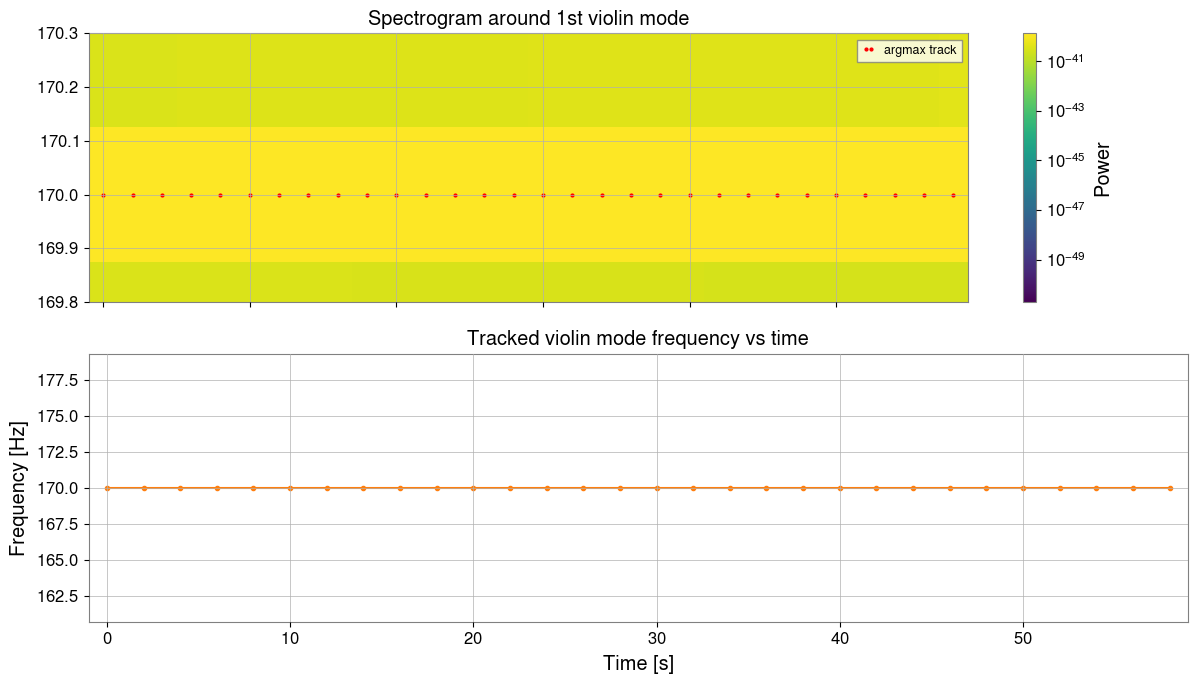

Total frequency drift: 0.00 mHz over 60 s


In [6]:
# ── Generate 60-s time-varying violin signal ──────────────────────────────────
DURATION = 60
FS_VIOL  = 4096
t_viol   = np.arange(0, DURATION, 1.0 / FS_VIOL)

# Linear drift: f0 = 170.0 → 170.02 Hz over 60 s (temperature effect)
f0_drift = 170.0 + (0.02 / DURATION) * t_viol
phi_viol = 2 * np.pi * np.cumsum(f0_drift) / FS_VIOL
sig_viol = 1e-20 * np.sin(phi_viol)
noise_v  = rng.normal(0, 3e-22, len(t_viol))

ts_viol   = TimeSeries(sig_viol + noise_v, dt=1.0 / FS_VIOL,
                       name="DARM_violin", unit="strain")

# ── Spectrogram ───────────────────────────────────────────────────────────────
spec_viol = ts_viol.spectrogram2(4.0, overlap=2.0)
times_v   = spec_viol.times.value
freqs_v   = spec_viol.frequencies.value

# ── Track via argmax in band ──────────────────────────────────────────────────
TRACK_BAND = (169.8, 170.3)
band_mask  = (freqs_v >= TRACK_BAND[0]) & (freqs_v <= TRACK_BAND[1])
track_viol = np.full(spec_viol.shape[0], np.nan)

for t_idx in range(spec_viol.shape[0]):
    row_band = spec_viol.value[t_idx, band_mask]
    if row_band.max() > 0:
        track_viol[t_idx] = freqs_v[band_mask][np.argmax(row_band)]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

_im_v = axes[0].pcolormesh(spec_viol.times.value, spec_viol.frequencies.value, spec_viol.value.T, norm=__import__("matplotlib.colors", fromlist=["LogNorm"]).LogNorm(), cmap="viridis", shading="auto")
axes[0].set_ylim(*TRACK_BAND)
axes[0].set_title("Spectrogram around 1st violin mode")
fig.colorbar(_im_v, ax=axes[0], label="Power")
axes[0].plot(times_v, track_viol, "r.", ms=4, label="argmax track")
axes[0].legend(loc="upper right", fontsize=9)

mask_v = ~np.isnan(track_viol)
axes[1].plot(times_v[mask_v], track_viol[mask_v], "o-", ms=3, color="tab:orange")
axes[1].set_ylabel("Frequency [Hz]")
axes[1].set_xlabel("Time [s]")
axes[1].set_title("Tracked violin mode frequency vs time")

plt.tight_layout()
plt.show()

drift_total = np.nanmax(track_viol) - np.nanmin(track_viol)
print(f"Total frequency drift: {drift_total * 1e3:.2f} mHz over {DURATION} s")


## 7. まとめ

- フィット窓は 1 つの共振ファミリーを分離できる範囲に選ぶ。
- 導出した Q、FWHM、リングダウン時間は sanity check としても使う。
- 追跡失敗の多くはライン混雑や低 SNR が原因なので、ドリフト解釈は保守的に行う。


In [7]:
print("=" * 62)
print("Violin Mode Analysis — Key Parameters")
print("-" * 62)
rows = [
    ("f_n (n-th mode)",   "n / (2L) * sqrt(T / rho*A)"),
    ("Q value",           "f0 / FWHM  =  f0 * pi * tau"),
    ("FWHM (linewidth)",  "f0 / Q                [Hz]"),
    ("Ring-down tau",     "Q / (pi * f0)         [s]"),
    ("HWHM gamma",        "FWHM / 2              [Hz]"),
]
for name, formula in rows:
    print(f"  {name:<22} {formula}")
print("=" * 62)
print()
print("gwexpy API used:")
print("  FrequencySeries.fit('lorentzian_q', p0=...)  -- Q-value fit")
print("  lorentzian_q(freqs, A, x0, Q)               -- model evaluation")
print("  ts.spectrogram2(fftlen, overlap)             -- time tracking")


Violin Mode Analysis — Key Parameters
--------------------------------------------------------------
  f_n (n-th mode)        n / (2L) * sqrt(T / rho*A)
  Q value                f0 / FWHM  =  f0 * pi * tau
  FWHM (linewidth)       f0 / Q                [Hz]
  Ring-down tau          Q / (pi * f0)         [s]
  HWHM gamma             FWHM / 2              [Hz]

gwexpy API used:
  FrequencySeries.fit('lorentzian_q', p0=...)  -- Q-value fit
  lorentzian_q(freqs, A, x0, Q)               -- model evaluation
  ts.spectrogram2(fftlen, overlap)             -- time tracking
